# Logistic Regression 3 - The scikit-learn Way

> **MLCourse · Machine Learning · 02_logistic_regression**

The canonical classification workflow on sklearn's BUNDLED breast-cancer set
(561 patients, 30 real features, fully offline): split → Pipeline → CV →
metrics → coefficients → regularization (the C knob) in one friendly paragraph.

## What you'll learn
- `LogisticRegression` end-to-end with a leak-proof Pipeline
- The **C parameter** - Ridge's little sibling, minus the math
- L1 vs L2 penalty for classification in one paragraph
- Cross-validated accuracy + which features matter

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

## 1. Data - real diagnostic measurements

Target: `0 = malignant`, `1 = benign` - 212 vs 357. Features: radius, texture,
perimeter… plus their "worst" variants; expect strong correlations inside families.

In [2]:
cancer = load_breast_cancer(as_frame=True)
X, y = cancer.data, cancer.target

print(X.shape, "| class balance:", np.bincount(y), "(malignant, benign)")
display(X.iloc[:3, :6])          # first six columns only - there are 30!

(569, 30) | class balance: [212 357] (malignant, benign)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
0,17.99,10.38,122.8,1001.0,0.11840,0.27760
1,20.57,17.77,132.9,1326.0,0.08474,0.07864
2,19.69,21.25,130.0,1203.0,0.10960,0.15990


## 2. Split + Pipeline (scaling INSIDE, leakage OUTside)

In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=.25, random_state=42, stratify=y)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000)),      # default C=1.0 (mild L2)
]).fit(X_tr, y_tr)

pred = pipe.predict(X_te)
proba = pipe.predict_proba(X_te)[:, 1]                 # P(benign)

print("train acc:", round(pipe.score(X_tr, y_tr), 4))
print("test  acc:", round(accuracy_score(y_te, pred), 4))

cv = cross_val_score(pipe, X_tr, y_tr, cv=5, scoring="accuracy")
print(f"5-fold CV acc: {cv.mean():.4f} ± {cv.std():.4f}")

pd.DataFrame(confusion_matrix(y_te, pred),
             index=["true malignant", "true benign"],
             columns=["pred malignant", "pred benign"])

train acc: 0.9883
test  acc: 0.986
5-fold CV acc: 0.9695 ± 0.0095


,pred malignant,pred benign
true malignant,52,1
true benign,1,89


> 💡 Full metric tour (precision/recall/ROC-AUC) lives in notebook 04 - here we
just confirm the model is healthy.

## 3. The C parameter - regularization without tears

sklearn flips the usual α upside down:

$$\text{small } C \;=\; \text{STRONG shrinkage} \qquad \text{large } C \;=\; \text{almost plain fit}$$

Same idea as Ridge α from linear regression, just inverted and built into
`LogisticRegression(C=...)`. Sweep it and watch test accuracy:

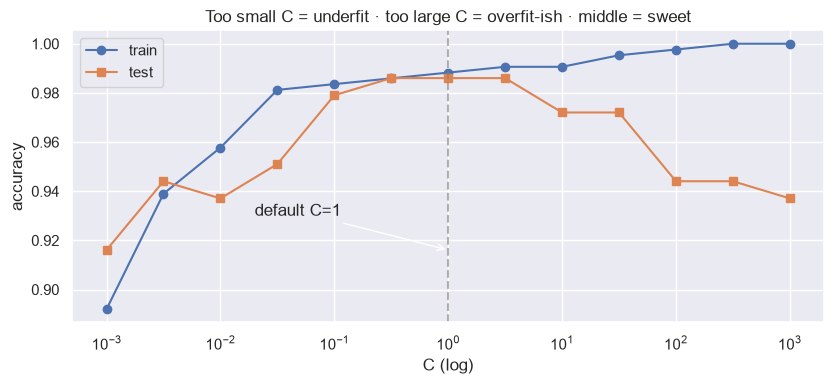

best test C = 0.316 with acc 0.9860


In [4]:
C_grid = np.logspace(-3, 3, 13)
tr_scores, te_scores = [], []
for c_val in C_grid:
    m = Pipeline([("sc", StandardScaler()),
                  ("m", LogisticRegression(C=c_val, max_iter=5000))]).fit(X_tr, y_tr)
    tr_scores.append(m.score(X_tr, y_tr))
    te_scores.append(m.score(X_te, y_te))

plt.figure(figsize=(8.5, 4))
plt.semilogx(C_grid, tr_scores, "o-", label="train")
plt.semilogx(C_grid, te_scores, "s-", label="test")
plt.axvline(1.0, ls="--", c="gray", alpha=.6)
plt.annotate("default C=1", (1, min(te_scores)), xytext=(0.02, .93),
             arrowprops=dict(arrowstyle="->"))
plt.xlabel("C (log)"); plt.ylabel("accuracy")
plt.title("Too small C = underfit · too large C = overfit-ish · middle = sweet")
plt.legend(); plt.tight_layout(); plt.show()

best_c = C_grid[int(np.argmax(te_scores))]
print(f"best test C = {best_c:.3g} with acc {max(te_scores):.4f}")

### L1 vs L2 in ONE paragraph

Exactly like linear regression: `penalty="l2"` shrinks all weights toward zero
but keeps every feature; `penalty="l1"` can zero-out useless features entirely
(built-in selection). Try L1 once - count survivors:

In [5]:
l1_model = Pipeline([("sc", StandardScaler()),
                     ("m", LogisticRegression(penalty="l1", C=0.5,
                                              solver="liblinear",
                                              max_iter=5000))]).fit(X_tr, y_tr)
coefs_l1 = pd.Series(l1_model.named_steps["m"].coef_[0], index=X.columns)
kept = int((coefs_l1.abs() > 1e-6).sum())
print(f"L1 kept {kept} of {X.shape[1]} features "
      f"| test acc {l1_model.score(X_te, y_te):.4f} (vs L2 {pipe.score(X_te, y_te):.4f})")

L1 kept 12 of 30 features | test acc 0.9860 (vs L2 0.9860)


D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## 4. Which measurements drive the diagnosis?

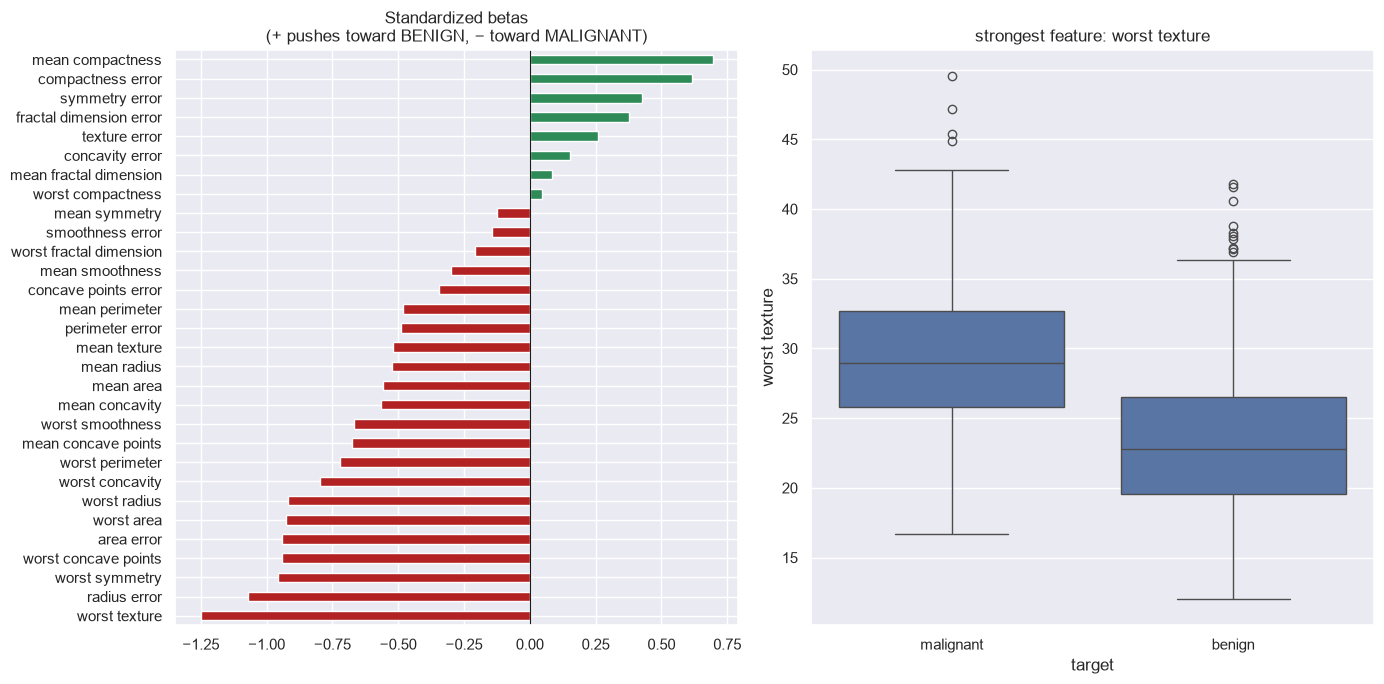

,worst texture,radius error,worst symmetry,worst concave points,area error,worst area,worst radius,worst concavity,worst perimeter,mean concave points,worst smoothness,mean concavity
beta,-1.25,-1.07,-0.96,-0.94,-0.94,-0.93,-0.92,-0.8,-0.72,-0.68,-0.67,-0.57


In [6]:
l2_model = pipe.named_steps["model"]
betas = pd.Series(l2_model.coef_[0], index=X.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
colors = ["firebrick" if v < 0 else "seagreen" for v in betas]
betas.plot(kind="barh", color=colors, ax=axes[0])
axes[0].axvline(0, c="k", lw=.8)
axes[0].set_title("Standardized betas\n(+ pushes toward BENIGN, − toward MALIGNANT)")

top10 = betas.abs().sort_values().tail(10).index
sns.boxplot(data=X.assign(target=y.map({0: "malignant", 1: "benign"})),
            x="target", y=top10[-1], ax=axes[1])
axes[1].set_title(f"strongest feature: {top10[-1]}")

plt.tight_layout(); plt.show()
display(betas.round(2).to_frame("beta").T.iloc[:, :12])

# Negative betas on size/worst-features make clinical sense: bigger, lumpier
# cells → more likely malignant.

## Summary & key takeaways

- Same professional loop as regression: split → Pipeline(scale→model) → CV →
  evaluate → interpret.
- **C is inverted strength**: small = humble model, large = flexible model;
  sweep on a log axis to see the underfit/overfit valley.
- `penalty="l1"` gives free feature selection (`solver="liblinear"` needed).
- Standardized coefficient signs already tell a clinical story - that's why
  logistic regression survives in regulated industries.